In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import interpolate
from matplotlib.collections import LineCollection
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [2]:
plt.style.use("dstyle")
_ = plt.figure()
plt.style.use("dstyle")

<Figure size 3000x2400 with 0 Axes>

In [3]:
MPC_CGS     = 3.0857e24
KM_CGS      = 1.e5
GYRS_CGS    = 3.1536e16

H0_DESI = 67.97
H0_Pantheon = 68.03
H0_Union3 = 66.53
H0_DESY5 = 67.24

H0_cgs_DESICMB = H0_DESI * (KM_CGS / MPC_CGS)
H0_cgs_Pantheon = H0_Pantheon * (KM_CGS / MPC_CGS)
H0_cgs_Union3 = H0_Union3 * (KM_CGS / MPC_CGS)
H0_cgs_DESY5 = H0_DESY5 * (KM_CGS / MPC_CGS)

In [4]:
table_fname_DESICMB = "integration_tables/table_DESI.txt"
table_fname_Pantheon = "integration_tables/table_Pantheon.txt"
table_fname_Union3 = "integration_tables/table_Union3.txt"
table_fname_DESY5 = "integration_tables/table_DESY5.txt"

nskiprows = 10

table_DESICMB = np.loadtxt(table_fname_DESICMB, skiprows=nskiprows, delimiter = ',')
table_Pantheon = np.loadtxt(table_fname_Pantheon, skiprows=nskiprows, delimiter = ',')
table_Union3 = np.loadtxt(table_fname_Union3, skiprows=nskiprows, delimiter = ',')
table_DESY5 = np.loadtxt(table_fname_DESY5, skiprows=nskiprows, delimiter = ',')

In [5]:
z_arr = table_DESICMB[:,0]
l_z_arr = table_DESICMB[:,1]
a_arr = table_DESICMB[:,2]

time_look_DESICMB = table_DESICMB[:,3]
time_age_DESICMB = table_DESICMB[:,4]
time_ageGyr_DESICMB = time_age_DESICMB / H0_cgs_DESICMB / GYRS_CGS

time_look_Pantheon = table_Pantheon[:,3]
time_age_Pantheon = table_Pantheon[:,4]
time_ageGyr_Pantheon = time_age_Pantheon / H0_cgs_Pantheon / GYRS_CGS

time_look_Union3 = table_Union3[:,3]
time_age_Union3 = table_Union3[:,4]
time_ageGyr_Union3 = time_age_Union3 / H0_cgs_Union3 / GYRS_CGS

time_look_DESY5 = table_DESY5[:,3]
time_age_DESY5 = table_DESY5[:,4]
time_ageGyr_DESY5 = time_age_DESY5 / H0_cgs_DESY5 / GYRS_CGS

In [6]:
strlabel_DESICMB = r"$\rm{DESI+CMB}$"
strlabel_Pantheon = r"$\rm{DESI+CMB+Pantheon}$"
strlabel_DESY5 = r"$\rm{DESI+CMB+DESY5}$"
strlabel_Union3 = r"$\rm{DESI+CMB+Union3}$"

In [7]:
def a2z(a):
    return (1. / a) - 1.

def z2a(z):
    return 1. / (1. + z)



In [8]:
redshifts_lookref = np.array([0.5, 1.0, 2.0])
a_lookref = 1. / (1. + redshifts_lookref)
a_lookref_0, a_lookref_1, a_lookref_2 = a_lookref
strlabel_lookref_0 = rf"$z = {redshifts_lookref[0]:.2f}$"
strlabel_lookref_1 = rf"$z = {redshifts_lookref[1]:.2f}$"
strlabel_lookref_2 = rf"$z = {redshifts_lookref[2]:.2f}$"

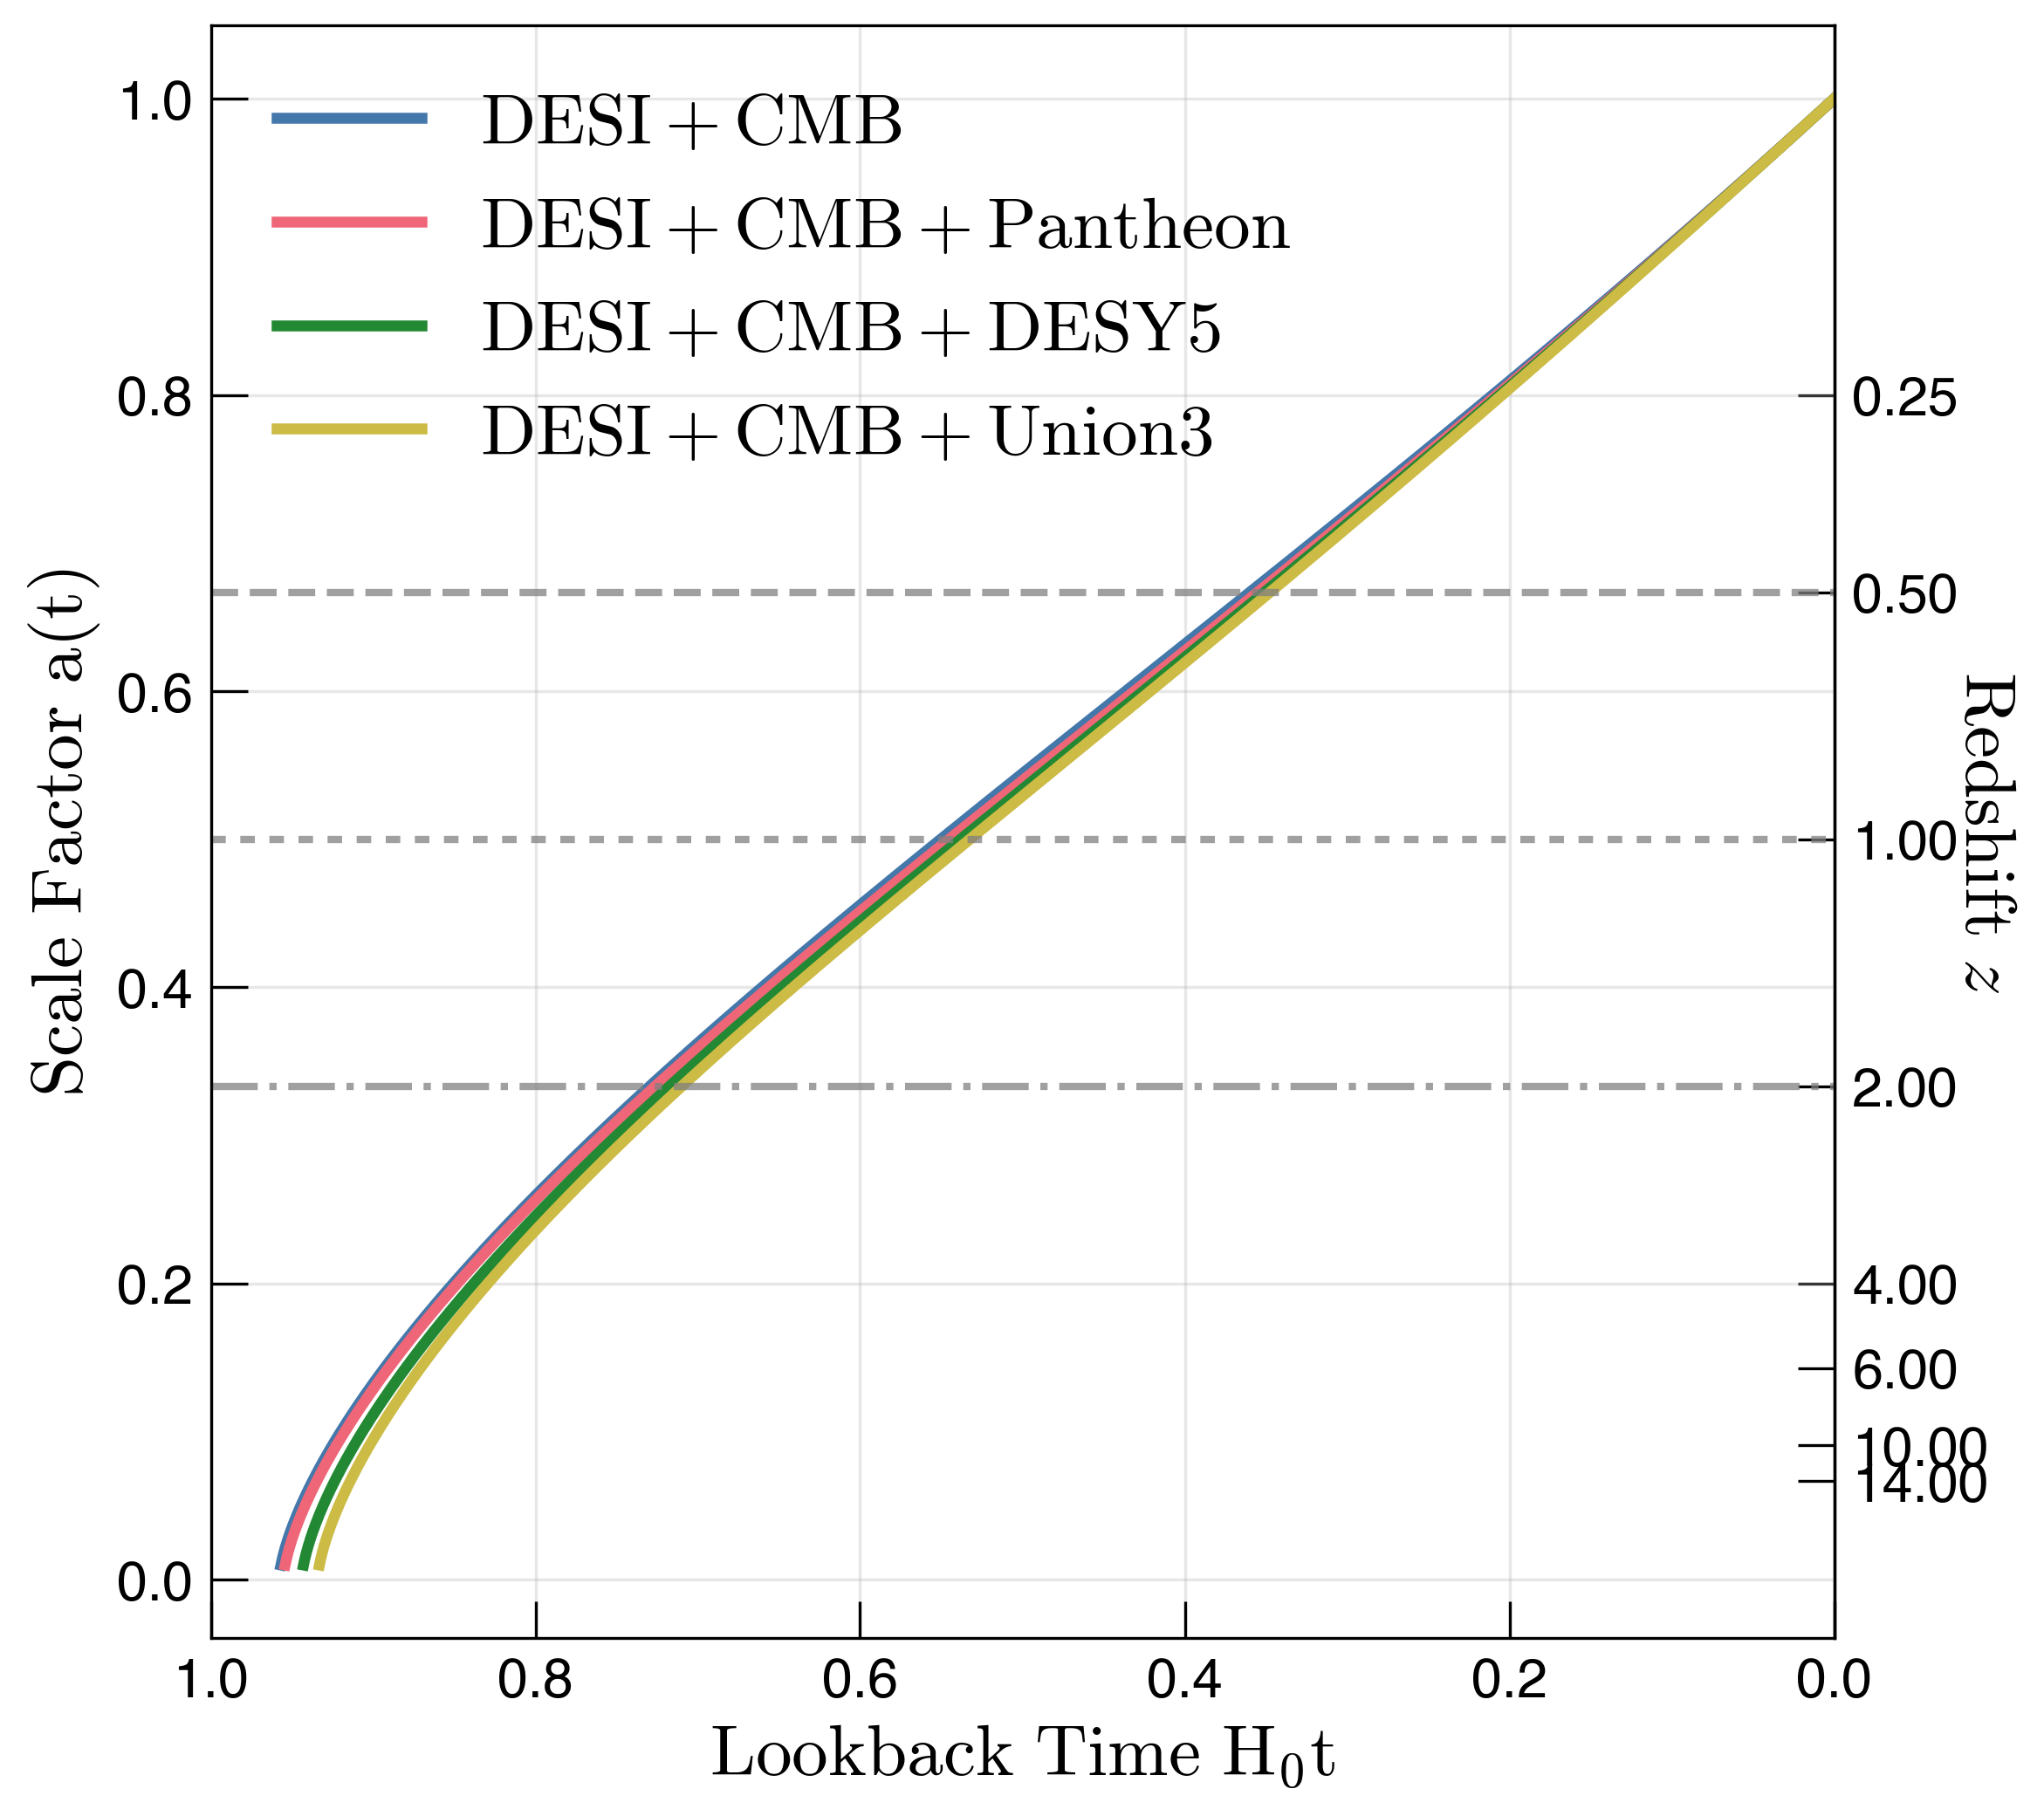

In [9]:
fig, ax = plt.subplots(figsize=(8,8), nrows=1, ncols=1)

_ = ax.plot(time_look_DESICMB, a_arr, label=strlabel_DESICMB, lw=3)
_ = ax.plot(time_look_Pantheon, a_arr, label=strlabel_Pantheon, lw=3)
_ = ax.plot(time_look_DESY5, a_arr, label=strlabel_DESY5, lw=3)
_ = ax.plot(time_look_Union3, a_arr, label=strlabel_Union3, lw=3)

_ = ax.axhline(a_lookref_0, c='gray', ls='--', lw=2, alpha=0.75)
_ = ax.axhline(a_lookref_1, c='gray', ls=':', lw=2, alpha=0.75)
_ = ax.axhline(a_lookref_2, c='gray', ls='-.', lw=2, alpha=0.75)

_ = ax.set_xlabel(r"$\rm{Lookback}\  \rm{Time}\ H_0 t$", fontsize=20)
_ = ax.set_ylabel(r"$\rm{Scale}\ \rm{Factor}\ a(t) $", fontsize=20)

_ = ax.set_xlim(1.0,0.)

ax2y = ax.secondary_yaxis('right', functions=(a2z, z2a))
_ = ax2y.set_yticks([0.25, 0.5, 1., 2., 4., 6., 10., 14])
_ = ax2y.set_ylabel(r"$\rm{Redshift}$" + r"$\ z$", rotation=270, labelpad=8, fontsize=20)

_ = ax.grid(alpha=0.3)

_ = plt.legend(loc='upper left')

In [10]:
agefn_DESICMB = interpolate.interp1d(z_arr, time_ageGyr_DESICMB)
agefn_Union3 = interpolate.interp1d(z_arr, time_ageGyr_Union3)
agefn_Pantheon = interpolate.interp1d(z_arr, time_ageGyr_Pantheon)
agefn_DESY5 = interpolate.interp1d(z_arr, time_ageGyr_DESY5)

scalefn_DESICMB = interpolate.interp1d(time_look_DESICMB, a_arr)

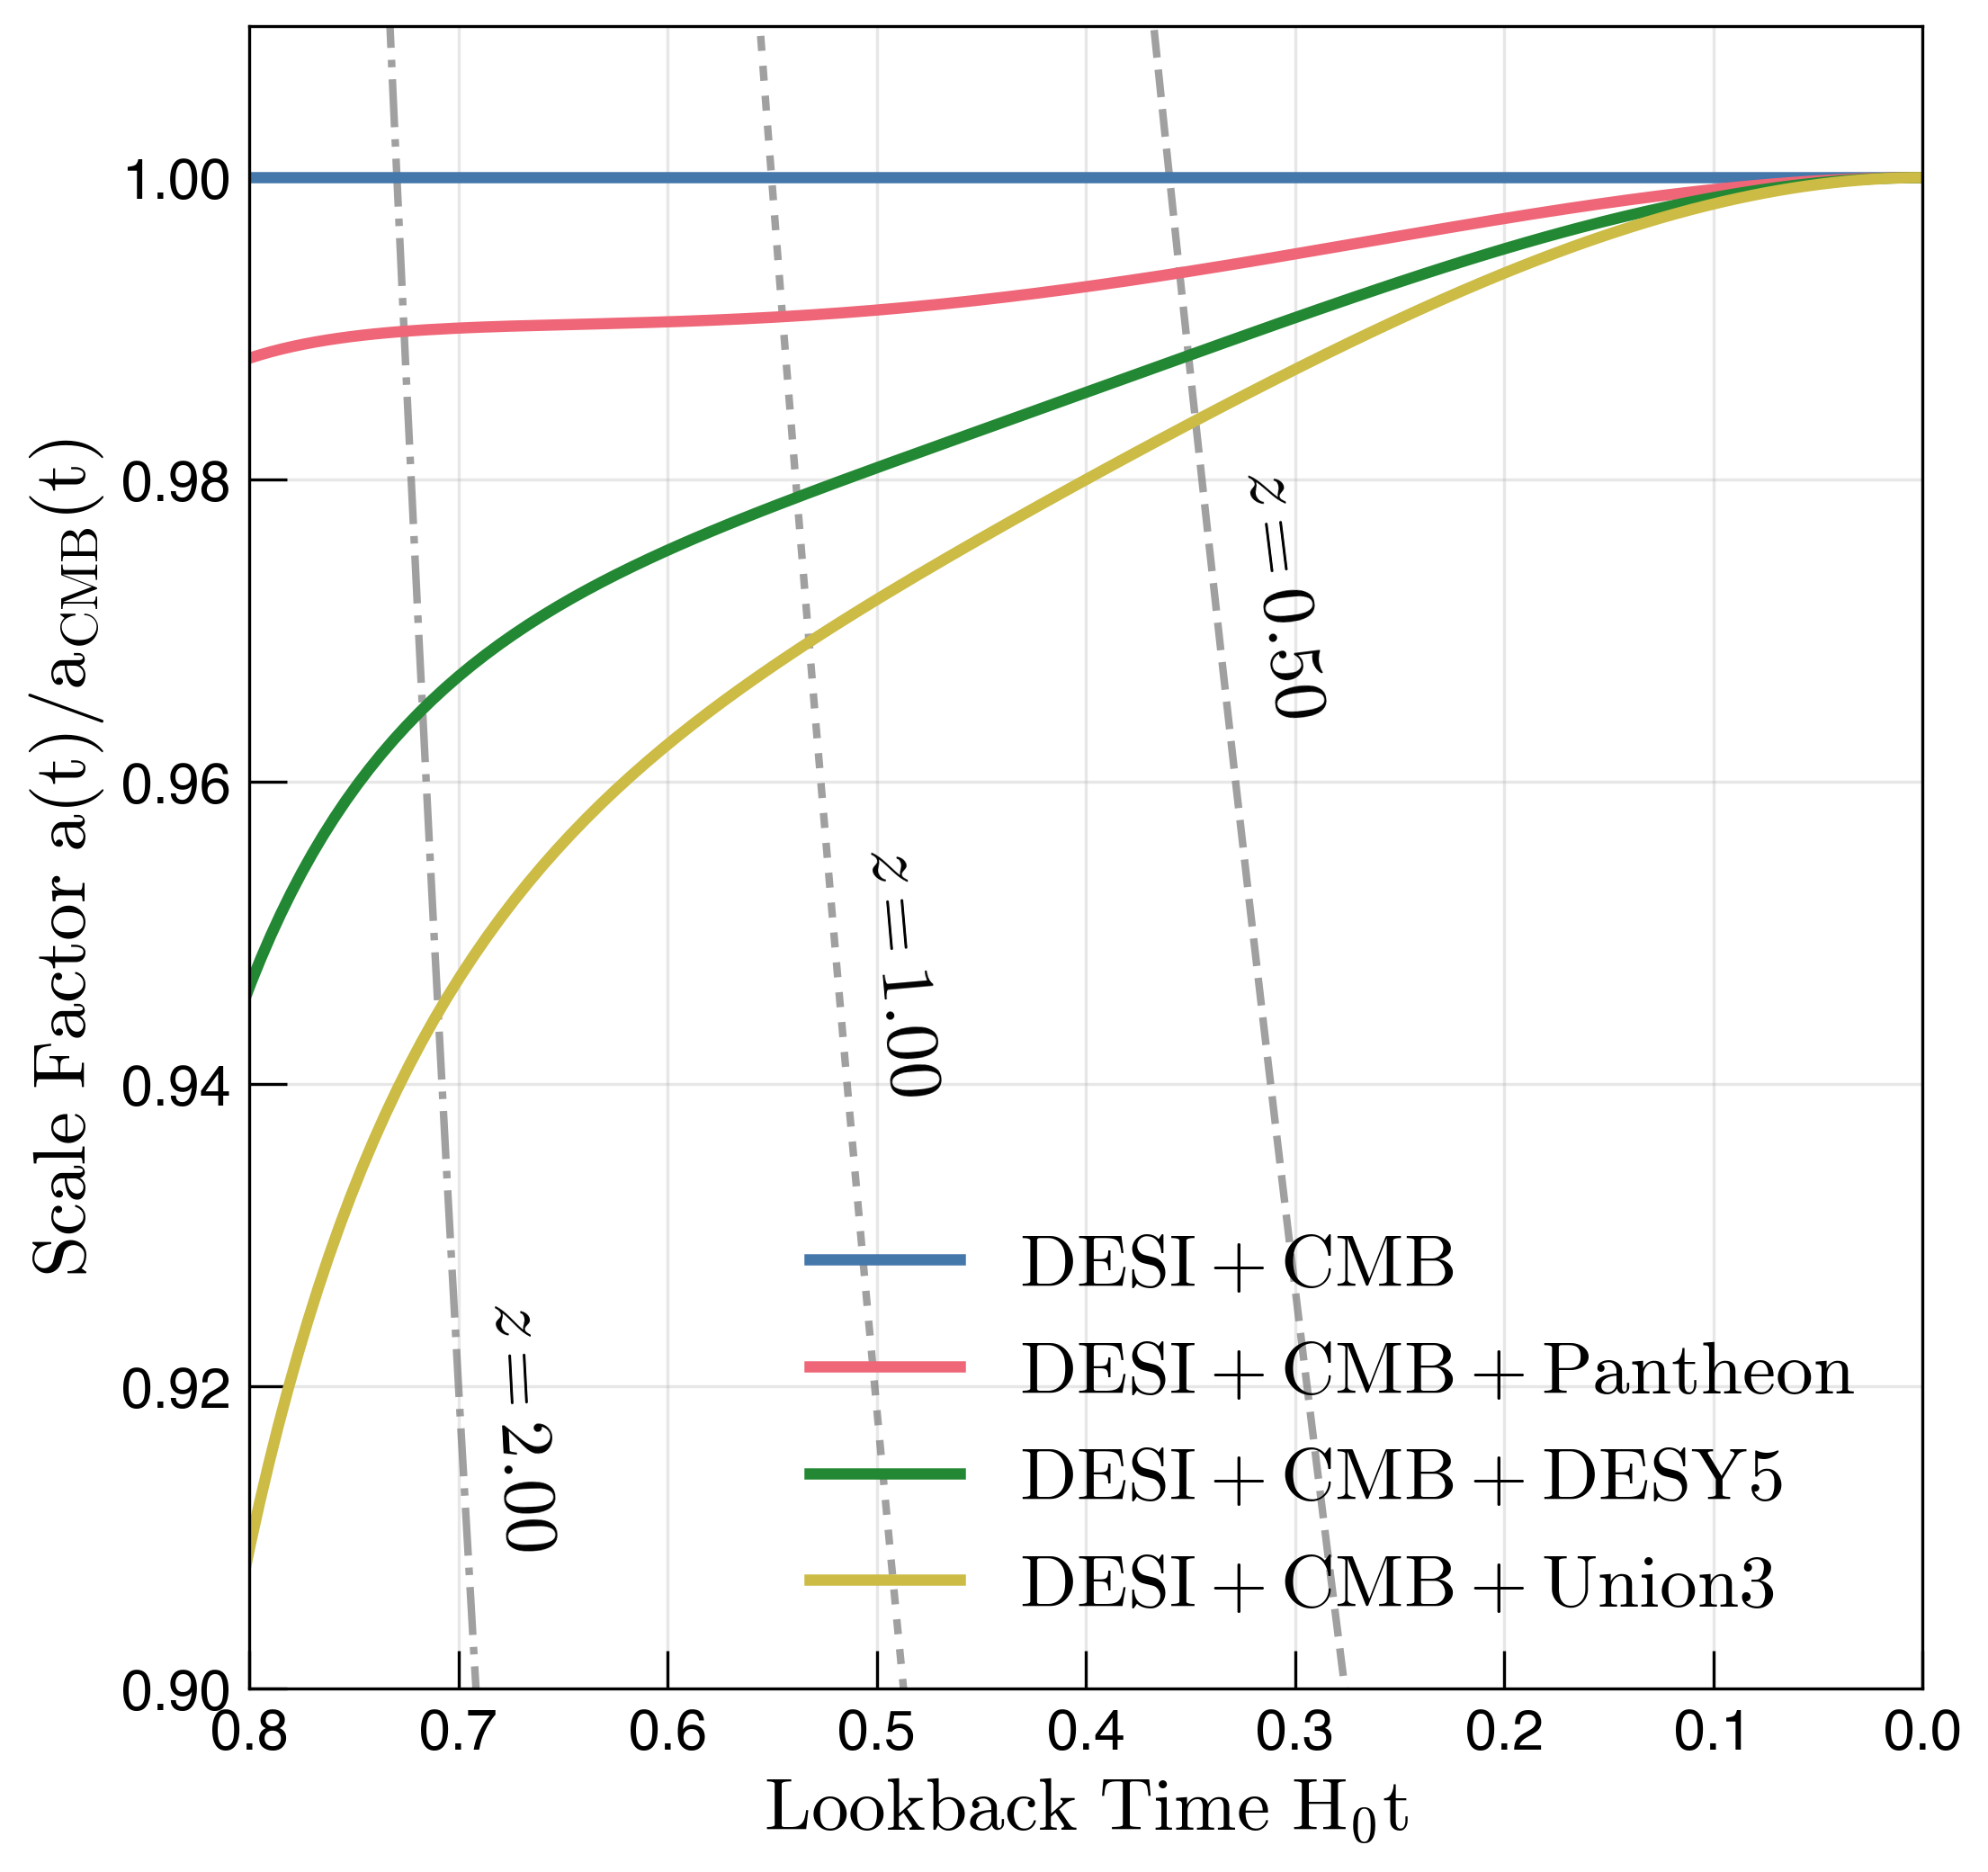

In [11]:
fig, ax = plt.subplots(figsize=(8,8), nrows=1, ncols=1)

aDESICMB_Concordance = scalefn_DESICMB(time_look_DESICMB[1:])
aPantheon_Concordance = scalefn_DESICMB(time_look_Pantheon[1:])
aDESY5_Concordance = scalefn_DESICMB(time_look_DESY5[1:])
aUnion3_Concordance = scalefn_DESICMB(time_look_Union3[1:])


_ = ax.plot(time_look_DESICMB, a_lookref_0 / scalefn_DESICMB(time_look_DESICMB), 
            c='gray', ls='--', lw=2, alpha=0.75)
_ = ax.plot(time_look_DESICMB, a_lookref_1 / scalefn_DESICMB(time_look_DESICMB), 
            c='gray', ls=':', lw=2, alpha=0.75)
_ = ax.plot(time_look_DESICMB, a_lookref_2 / scalefn_DESICMB(time_look_DESICMB), 
            c='gray', ls='-.', lw=2, alpha=0.75)

_ = ax.plot(time_look_DESICMB[1:], a_arr[1:]/aDESICMB_Concordance, label=strlabel_DESICMB, lw=3)
_ = ax.plot(time_look_Pantheon[1:], a_arr[1:]/aPantheon_Concordance, label=strlabel_Pantheon, lw=3)
_ = ax.plot(time_look_DESY5[1:], a_arr[1:]/aDESY5_Concordance, label=strlabel_DESY5, lw=3)
_ = ax.plot(time_look_Union3[1:], a_arr[1:]/aUnion3_Concordance, label=strlabel_Union3, lw=3)


x_redshift = 0.33
y_redshift = 0.965
_ = ax.annotate(strlabel_lookref_0, xy=(x_redshift, y_redshift), fontsize=20, rotation=277)

x_redshift = 0.51
y_redshift = 0.94
_ = ax.annotate(strlabel_lookref_1, xy=(x_redshift, y_redshift), fontsize=20, rotation=275)

x_redshift = 0.69
y_redshift = 0.91
_ = ax.annotate(strlabel_lookref_2, xy=(x_redshift, y_redshift), fontsize=20, rotation=273)

_ = ax.set_xlabel(r"Lookback time ($H_0 t$)")
_ = ax.set_ylabel("scale factor ($a / a_{\Lambda}$)")

_ = ax.set_xlabel(r"$\rm{Lookback}\  \rm{Time}\ H_0 t$", fontsize=20)
_ = ax.set_ylabel(r"$\rm{Scale}\ \rm{Factor}\ a(t) / a_{\rm{CMB}}(t) $", fontsize=20)

_ = ax.set_xlim(0.8,0.)
_ = ax.set_ylim(0.90, 1.01)

_ = ax.grid(alpha=0.3)


legend_obj = plt.legend(loc='lower right', alignment='right')


_ = plt.savefig('Diff_Expansion_ZoomIn.png', bbox_inches='tight', dpi=256)

In [12]:
12 / (1417 / 693)

5.868736767819336

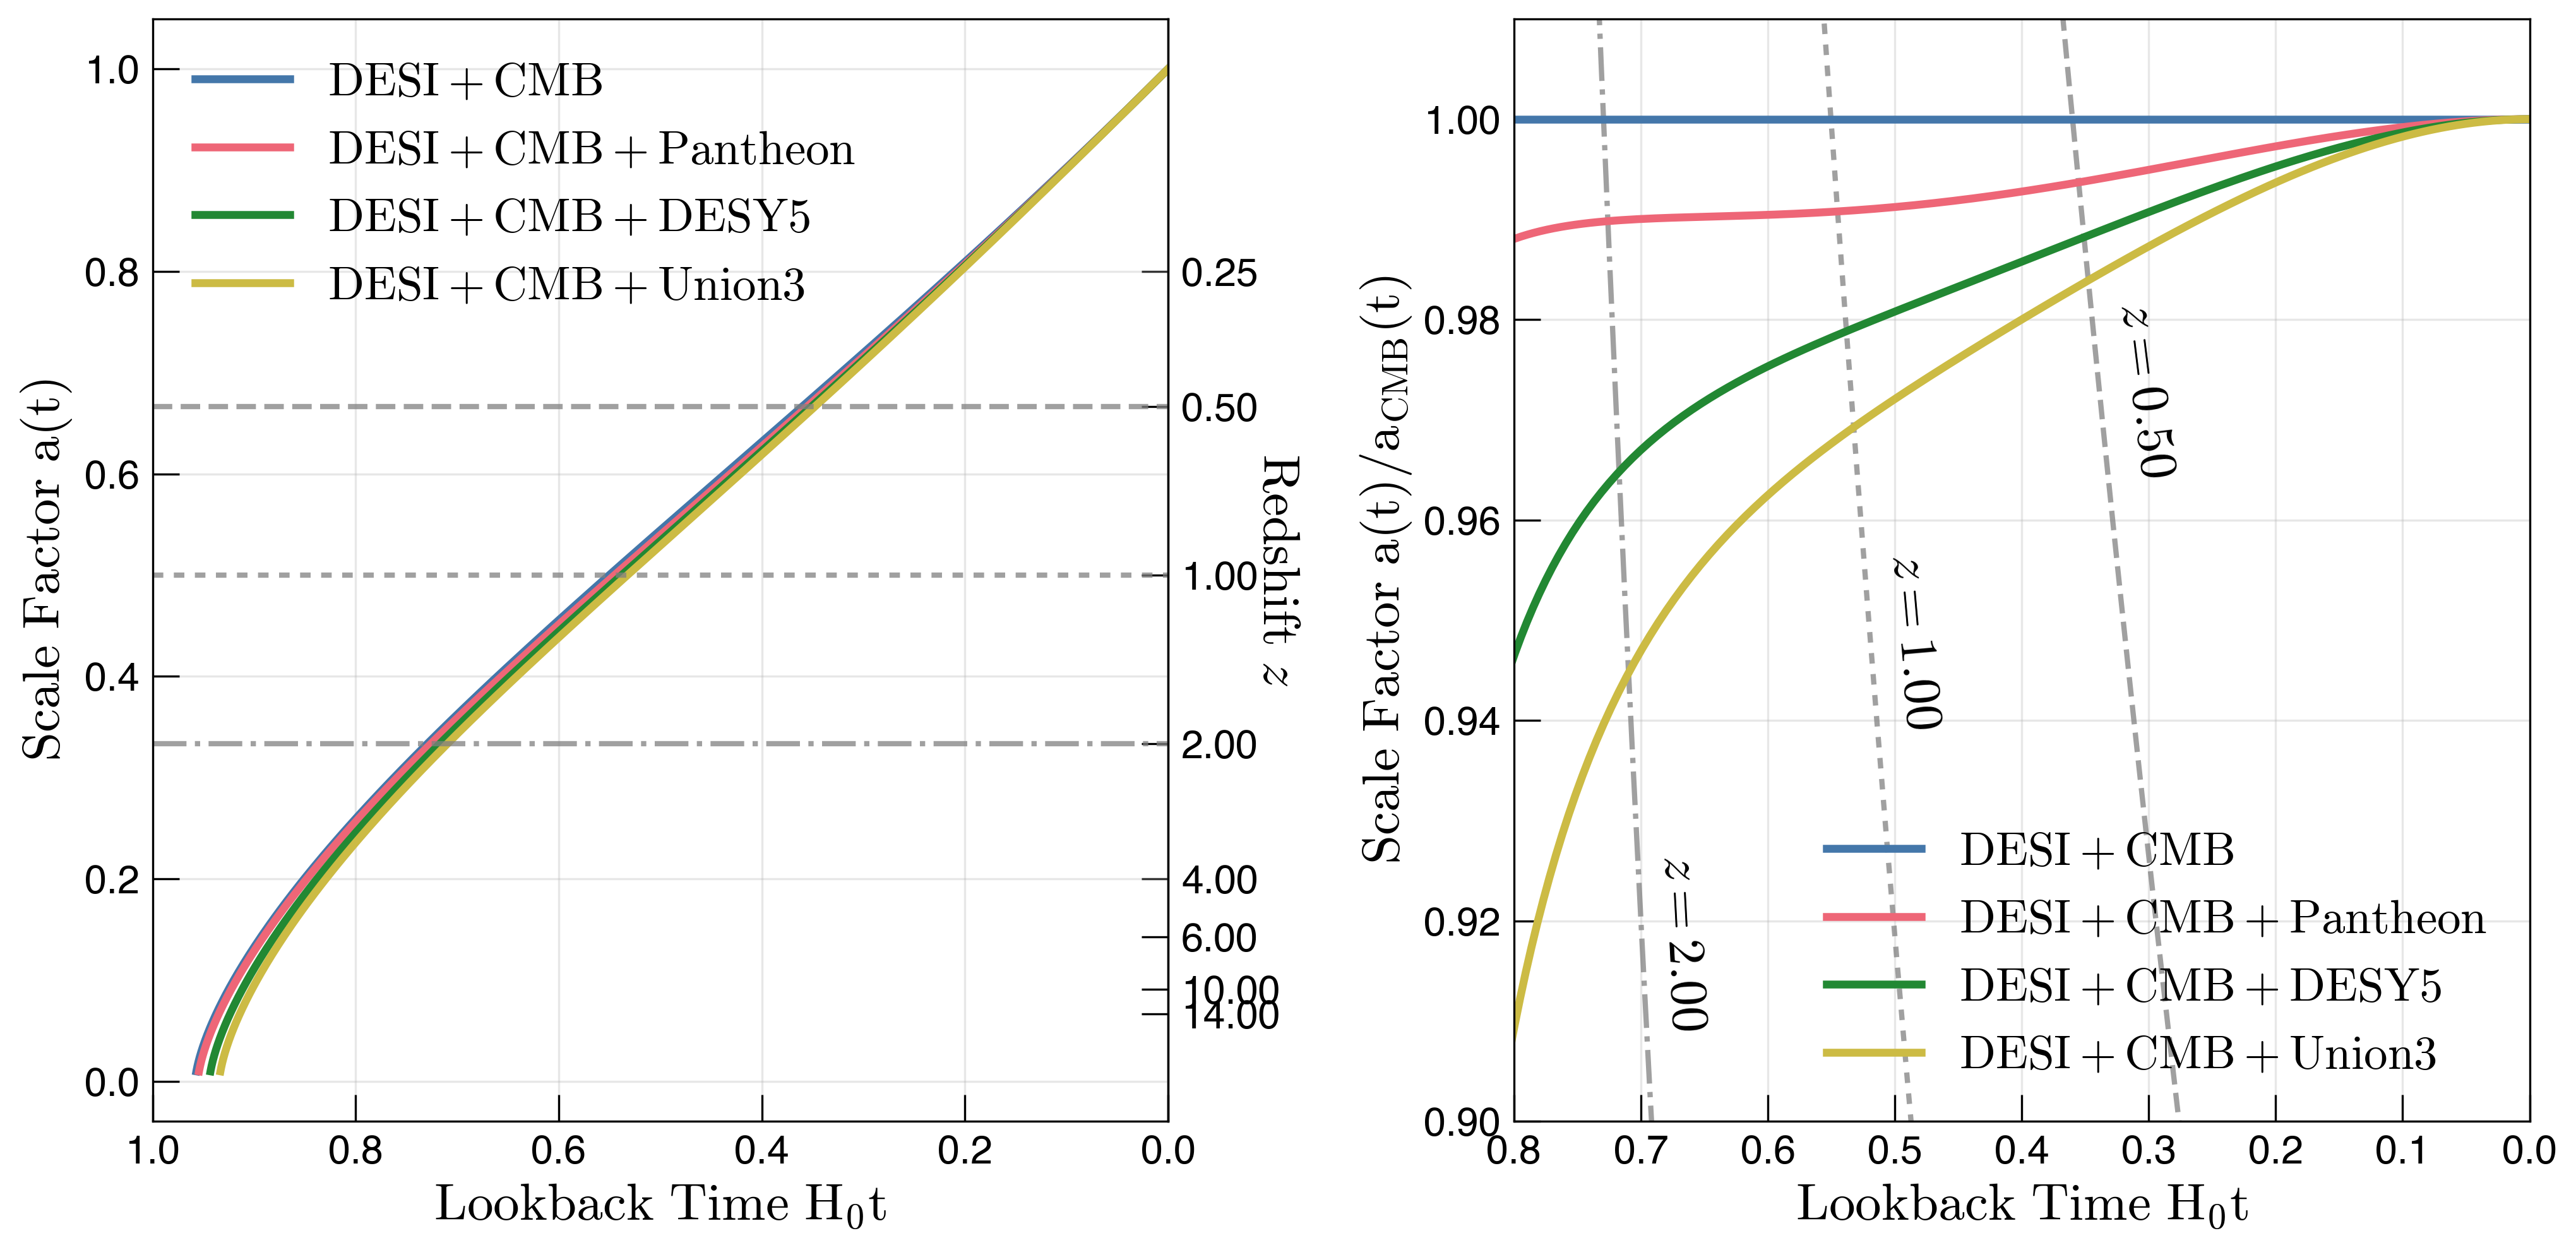

In [13]:
fig, ax_all = plt.subplots(figsize=(14,7), nrows=1, ncols=2)
ax_look, ax_lookdiff = ax_all



_ = ax_look.plot(time_look_DESICMB, a_arr, label=strlabel_DESICMB, lw=3)
_ = ax_look.plot(time_look_Pantheon, a_arr, label=strlabel_Pantheon, lw=3)
_ = ax_look.plot(time_look_DESY5, a_arr, label=strlabel_DESY5, lw=3)
_ = ax_look.plot(time_look_Union3, a_arr, label=strlabel_Union3, lw=3)


_ = ax_look.axhline(a_lookref_0, c='gray', ls='--', lw=2, alpha=0.75)
_ = ax_look.axhline(a_lookref_1, c='gray', ls=':', lw=2, alpha=0.75)
_ = ax_look.axhline(a_lookref_2, c='gray', ls='-.', lw=2, alpha=0.75)

_ = ax_look.set_xlabel(r"$\rm{Lookback}\  \rm{Time}\ H_0 t$", fontsize=20)
_ = ax_look.set_ylabel(r"$\rm{Scale}\ \rm{Factor}\ a(t) $", fontsize=20)

_ = ax_look.set_xlim(1.0,0.)

ax2y = ax_look.secondary_yaxis('right', functions=(a2z, z2a))
_ = ax2y.set_yticks([0.25, 0.5, 1., 2., 4., 6., 10., 14])
_ = ax2y.set_ylabel(r"$\rm{Redshift}$" + r"$\ z$", rotation=270, labelpad=8, fontsize=20)

_ = ax_look.grid(alpha=0.3)




_ = ax_lookdiff.plot(time_look_DESICMB, a_lookref_0 / scalefn_DESICMB(time_look_DESICMB), 
            c='gray', ls='--', lw=2, alpha=0.75)
_ = ax_lookdiff.plot(time_look_DESICMB, a_lookref_1 / scalefn_DESICMB(time_look_DESICMB), 
            c='gray', ls=':', lw=2, alpha=0.75)
_ = ax_lookdiff.plot(time_look_DESICMB, a_lookref_2 / scalefn_DESICMB(time_look_DESICMB), 
            c='gray', ls='-.', lw=2, alpha=0.75)

x_redshift = 0.33
y_redshift = 0.965
_ = ax_lookdiff.annotate(strlabel_lookref_0, xy=(x_redshift, y_redshift), fontsize=20, rotation=277)

x_redshift = 0.51
y_redshift = 0.94
_ = ax_lookdiff.annotate(strlabel_lookref_1, xy=(x_redshift, y_redshift), fontsize=20, rotation=275)

x_redshift = 0.69
y_redshift = 0.91
_ = ax_lookdiff.annotate(strlabel_lookref_2, xy=(x_redshift, y_redshift), fontsize=20, rotation=273)


_ = ax_lookdiff.plot(time_look_DESICMB[1:], a_arr[1:]/aDESICMB_Concordance, label=strlabel_DESICMB, lw=3)
_ = ax_lookdiff.plot(time_look_Pantheon[1:], a_arr[1:]/aPantheon_Concordance, label=strlabel_Pantheon, lw=3)
_ = ax_lookdiff.plot(time_look_DESY5[1:], a_arr[1:]/aDESY5_Concordance, label=strlabel_DESY5, lw=3)
_ = ax_lookdiff.plot(time_look_Union3[1:], a_arr[1:]/aUnion3_Concordance, label=strlabel_Union3, lw=3)


_ = ax_lookdiff.set_xlabel(r"Lookback time ($H_0 t$)")
_ = ax_lookdiff.set_ylabel("scale factor ($a / a_{\Lambda}$)")

_ = ax_lookdiff.set_xlabel(r"$\rm{Lookback}\  \rm{Time}\ H_0 t$", fontsize=20)
_ = ax_lookdiff.set_ylabel(r"$\rm{Scale}\ \rm{Factor}\ a(t) / a_{\rm{CMB}}(t) $", fontsize=20)

_ = ax_lookdiff.set_xlim(0.8,0.)
_ = ax_lookdiff.set_ylim(0.90, 1.01)


for ax in ax_all:
    _ = ax.grid(alpha=0.3)

_ = ax_look.legend(loc='upper left', fontsize=18)
_ = ax_lookdiff.legend(loc='lower right', alignment='right', fontsize=18)

_ = fig.tight_layout()


_ = plt.savefig('Expansion_ZoomIn.png', bbox_inches='tight', dpi=256)

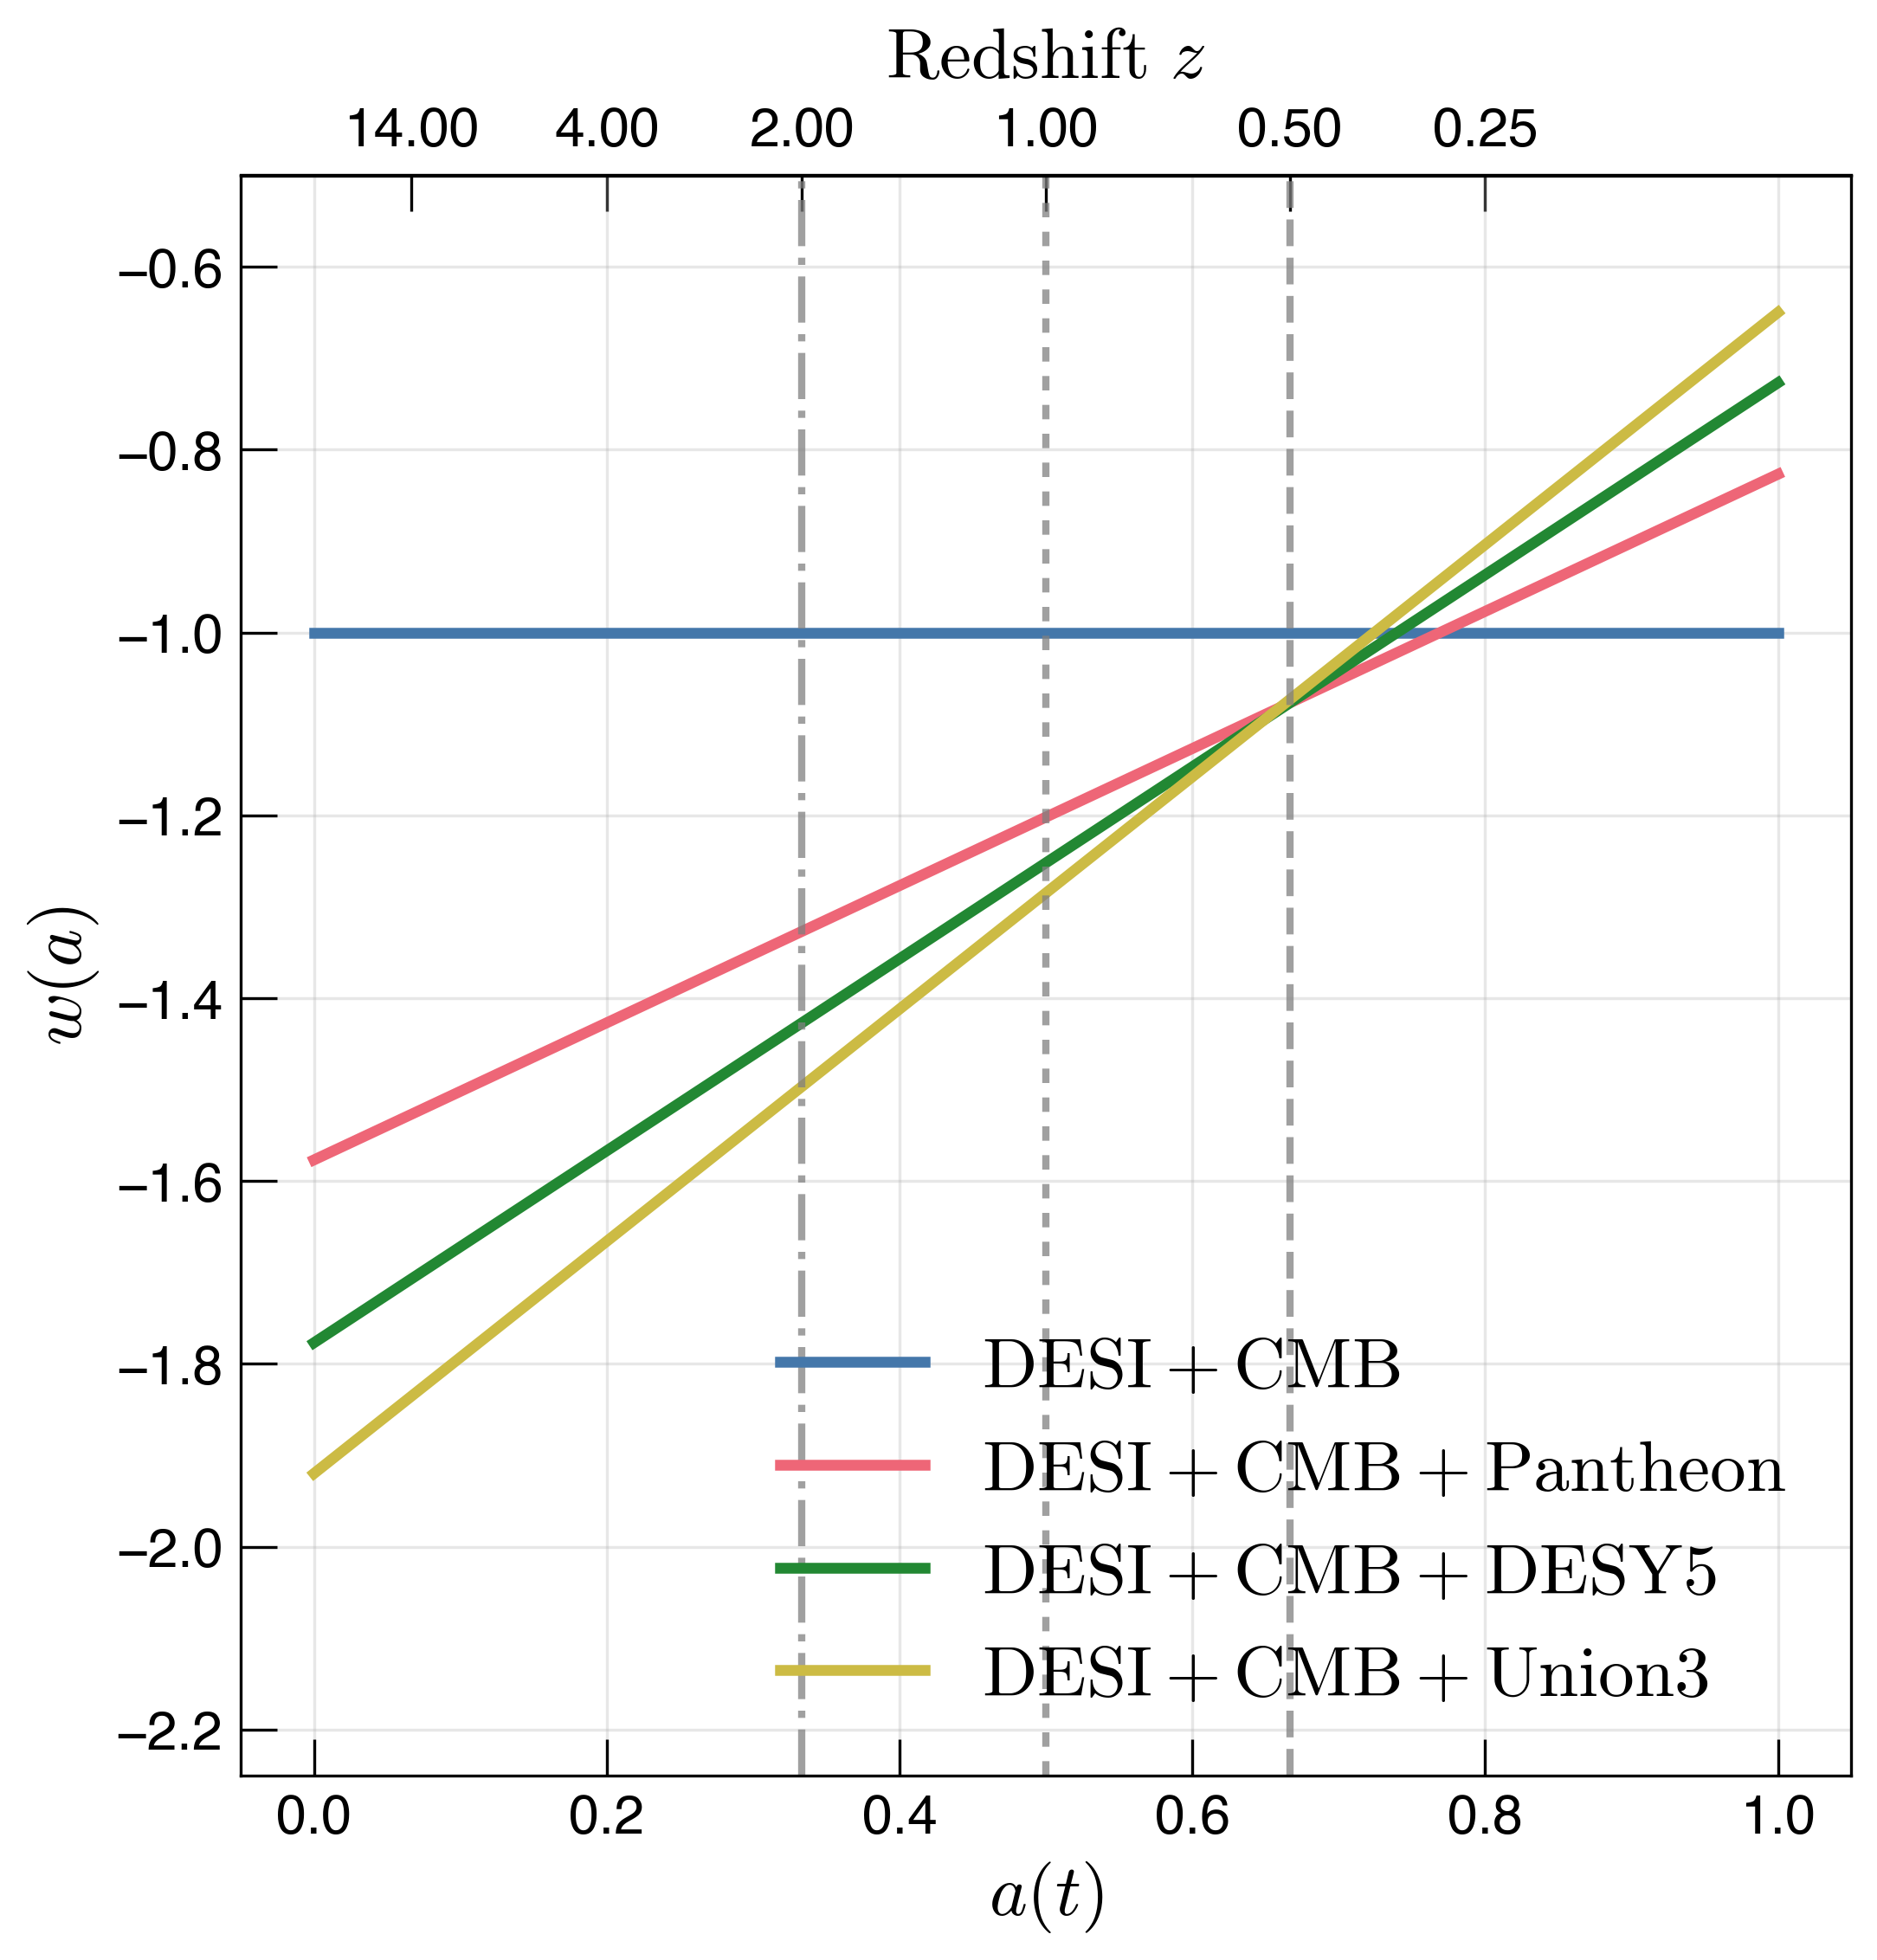

In [14]:
scale_factor = np.linspace(0.,1.)

def_arr = np.ones_like(scale_factor)
w_Radiation = 1. / 3. * def_arr
w_Matter = 0. * def_arr
w_Lambda = -1. * def_arr


w0_Pantheon, wa_Pantheon = -0.827, -0.750
w0_Union3, wa_Union3 = -0.650, -1.270
w0_DESY5, wa_DESY5 = -0.727, -1.050

wDE_Pantheon = w0_Pantheon + wa_Pantheon * (1. - scale_factor)
wDE_Union3 = w0_Union3 + wa_Union3 * (1. - scale_factor)
wDE_DESY5 = w0_DESY5 + wa_DESY5 * (1. - scale_factor)

fig, ax = plt.subplots(figsize=(8,8), nrows=1, ncols=1)

_ = ax.plot(scale_factor, w_Lambda, label=strlabel_DESICMB)
_ = ax.plot(scale_factor, wDE_Pantheon, label=strlabel_Pantheon)
_ = ax.plot(scale_factor, wDE_DESY5, label=strlabel_DESY5)
_ = ax.plot(scale_factor, wDE_Union3, label=strlabel_Union3)

_ = ax.axvline(a_lookref_0, c='gray', ls='--', lw=2, alpha=0.75)
_ = ax.axvline(a_lookref_1, c='gray', ls=':', lw=2, alpha=0.75)
_ = ax.axvline(a_lookref_2, c='gray', ls='-.', lw=2, alpha=0.75)

_ = ax.set_xlabel(r'$a(t)$', fontsize=20)
_ = ax.set_ylabel(r'$w(a)$', fontsize=20)

ax2x = ax.secondary_xaxis('top', functions=(a2z, z2a))
_ = ax2x.set_xticks([0.25, 0.5, 1., 2., 4., 14.])
_ = ax2x.set_xlabel(r"$\rm{Redshift}$" + r"$\ z$", fontsize=20, labelpad=8)

_ = ax.set_ylim(-2.25, -0.5)

_ = ax.legend(loc='lower right')
_ = ax.grid(alpha=0.3)

_ = plt.savefig('wEvolutionDESI.png', bbox_inches='tight', dpi=256)

$$
\Omega_{0,M} a^{-3(1+0)} = \Omega_{0,DE} a^{-3(1-w(a))} \rightarrow \Omega_{0,M} a^{-3} = \Omega_{0,DE} a^{3w(a)-3}
$$

$$
\frac{\Omega_{0,DE}}{\Omega_{0,M}} = \frac{a^{-3}}{a^{3w(a)-3}} = \frac{1}{a^{3w(a)}} = a^{-3w(a)}
$$

$$
w(a) = w_0 + w_a(1-a)
$$

$$
\frac{\Omega_{0,DE}}{\Omega_{0,M}} = a^{-3(w_0 + w_a(1-a))} = a^{-3w_0 -3 w_a(1-a))} = a^{-3w_0 -3 w_a + 3 w_a a} = a^{-3(w_0 + w_a)} a^{3 w_a a}
$$

How do species generally evolve

$$
\rho_i = \rho_{0,i} a^{-3(1+w)}
$$

Specify matter and dark energy

$$
\rho_{M} = \rho_{0,M} a^{-3(1+0)} = \rho_{0,M} a^{-3}
$$

$$
\rho_{DE} = \rho_{0,DE} a^{-3(1+w(a))}
$$

Detail $w(a)$

$$
w(a) = w_0 + w_a (1-a)
$$

$$
\rho_{DE} = \rho_{0,DE} a^{-3(1+w(a))} = \rho_{0,DE} a^{-3(1+w_0 + w_a (1-a))} 
$$

$$
\Omega_{M} = \frac{\rho_{0,M}}{\rho_{0,c}} a^{-3} = \Omega_{0,M} a^{-3}
$$

$$
\Omega_{DE} = \frac{\rho_{0,DE}}{\rho_{0,c}} a^{-3(1+w_0 + w_a (1-a))}  = \Omega_{0,DE} a^{-3(1+w_0 + w_a (1-a))} 
$$

Describe in terms of log

$$
\Omega_{M} \propto a^{-3}
$$

$$
\Omega_{DE} \propto a^{-3(1+w_0 + w_a (1-a))} 
$$


$$
\log \Omega_{M} \propto -3 \log a
$$

$$
\log \Omega_{DE} \propto -3(1+w_0 + w_a (1-a)) \log a 
$$

Detail in terms of present-day dark energy to matter energy measurement

$$
\frac{\Omega_{0,DE}}{\Omega_{0,M}} = A \rm{(measured)}
$$

$$
\Omega_{DE} = \Omega_{0,DE} a^{-3(1+w_0 + w_a (1-a))} = A \Omega_{0,M} a^{-3(1+w_0 + w_a (1-a))}
$$

$$
\log \Omega_{DE} = \log(A) + \log(\Omega_{0,M}) -3(1+w_0 + w_a (1-a)) \log a 
$$

$$
\log \Omega_{M} = \log \Omega_{0,M} -3 \log a
$$

Set $\log \Omega_{0,M} = 0$

$$
\log \Omega_{DE} = \log(A) -3(1+w_0 + w_a (1-a)) \log a 
$$

$$
\log \Omega_{M} = -3 \log a
$$

In [15]:
def la2l1z(la):
    return -1. * la

def l1z2la(l1z):
    return -1. * l1z





In [16]:
Lambda_label = r'$\Omega_{\Lambda}$'
Radiation_label = r'$\Omega_{\rm{R}}$'
Matter_label = r'$\Omega_{\rm{M}}$'

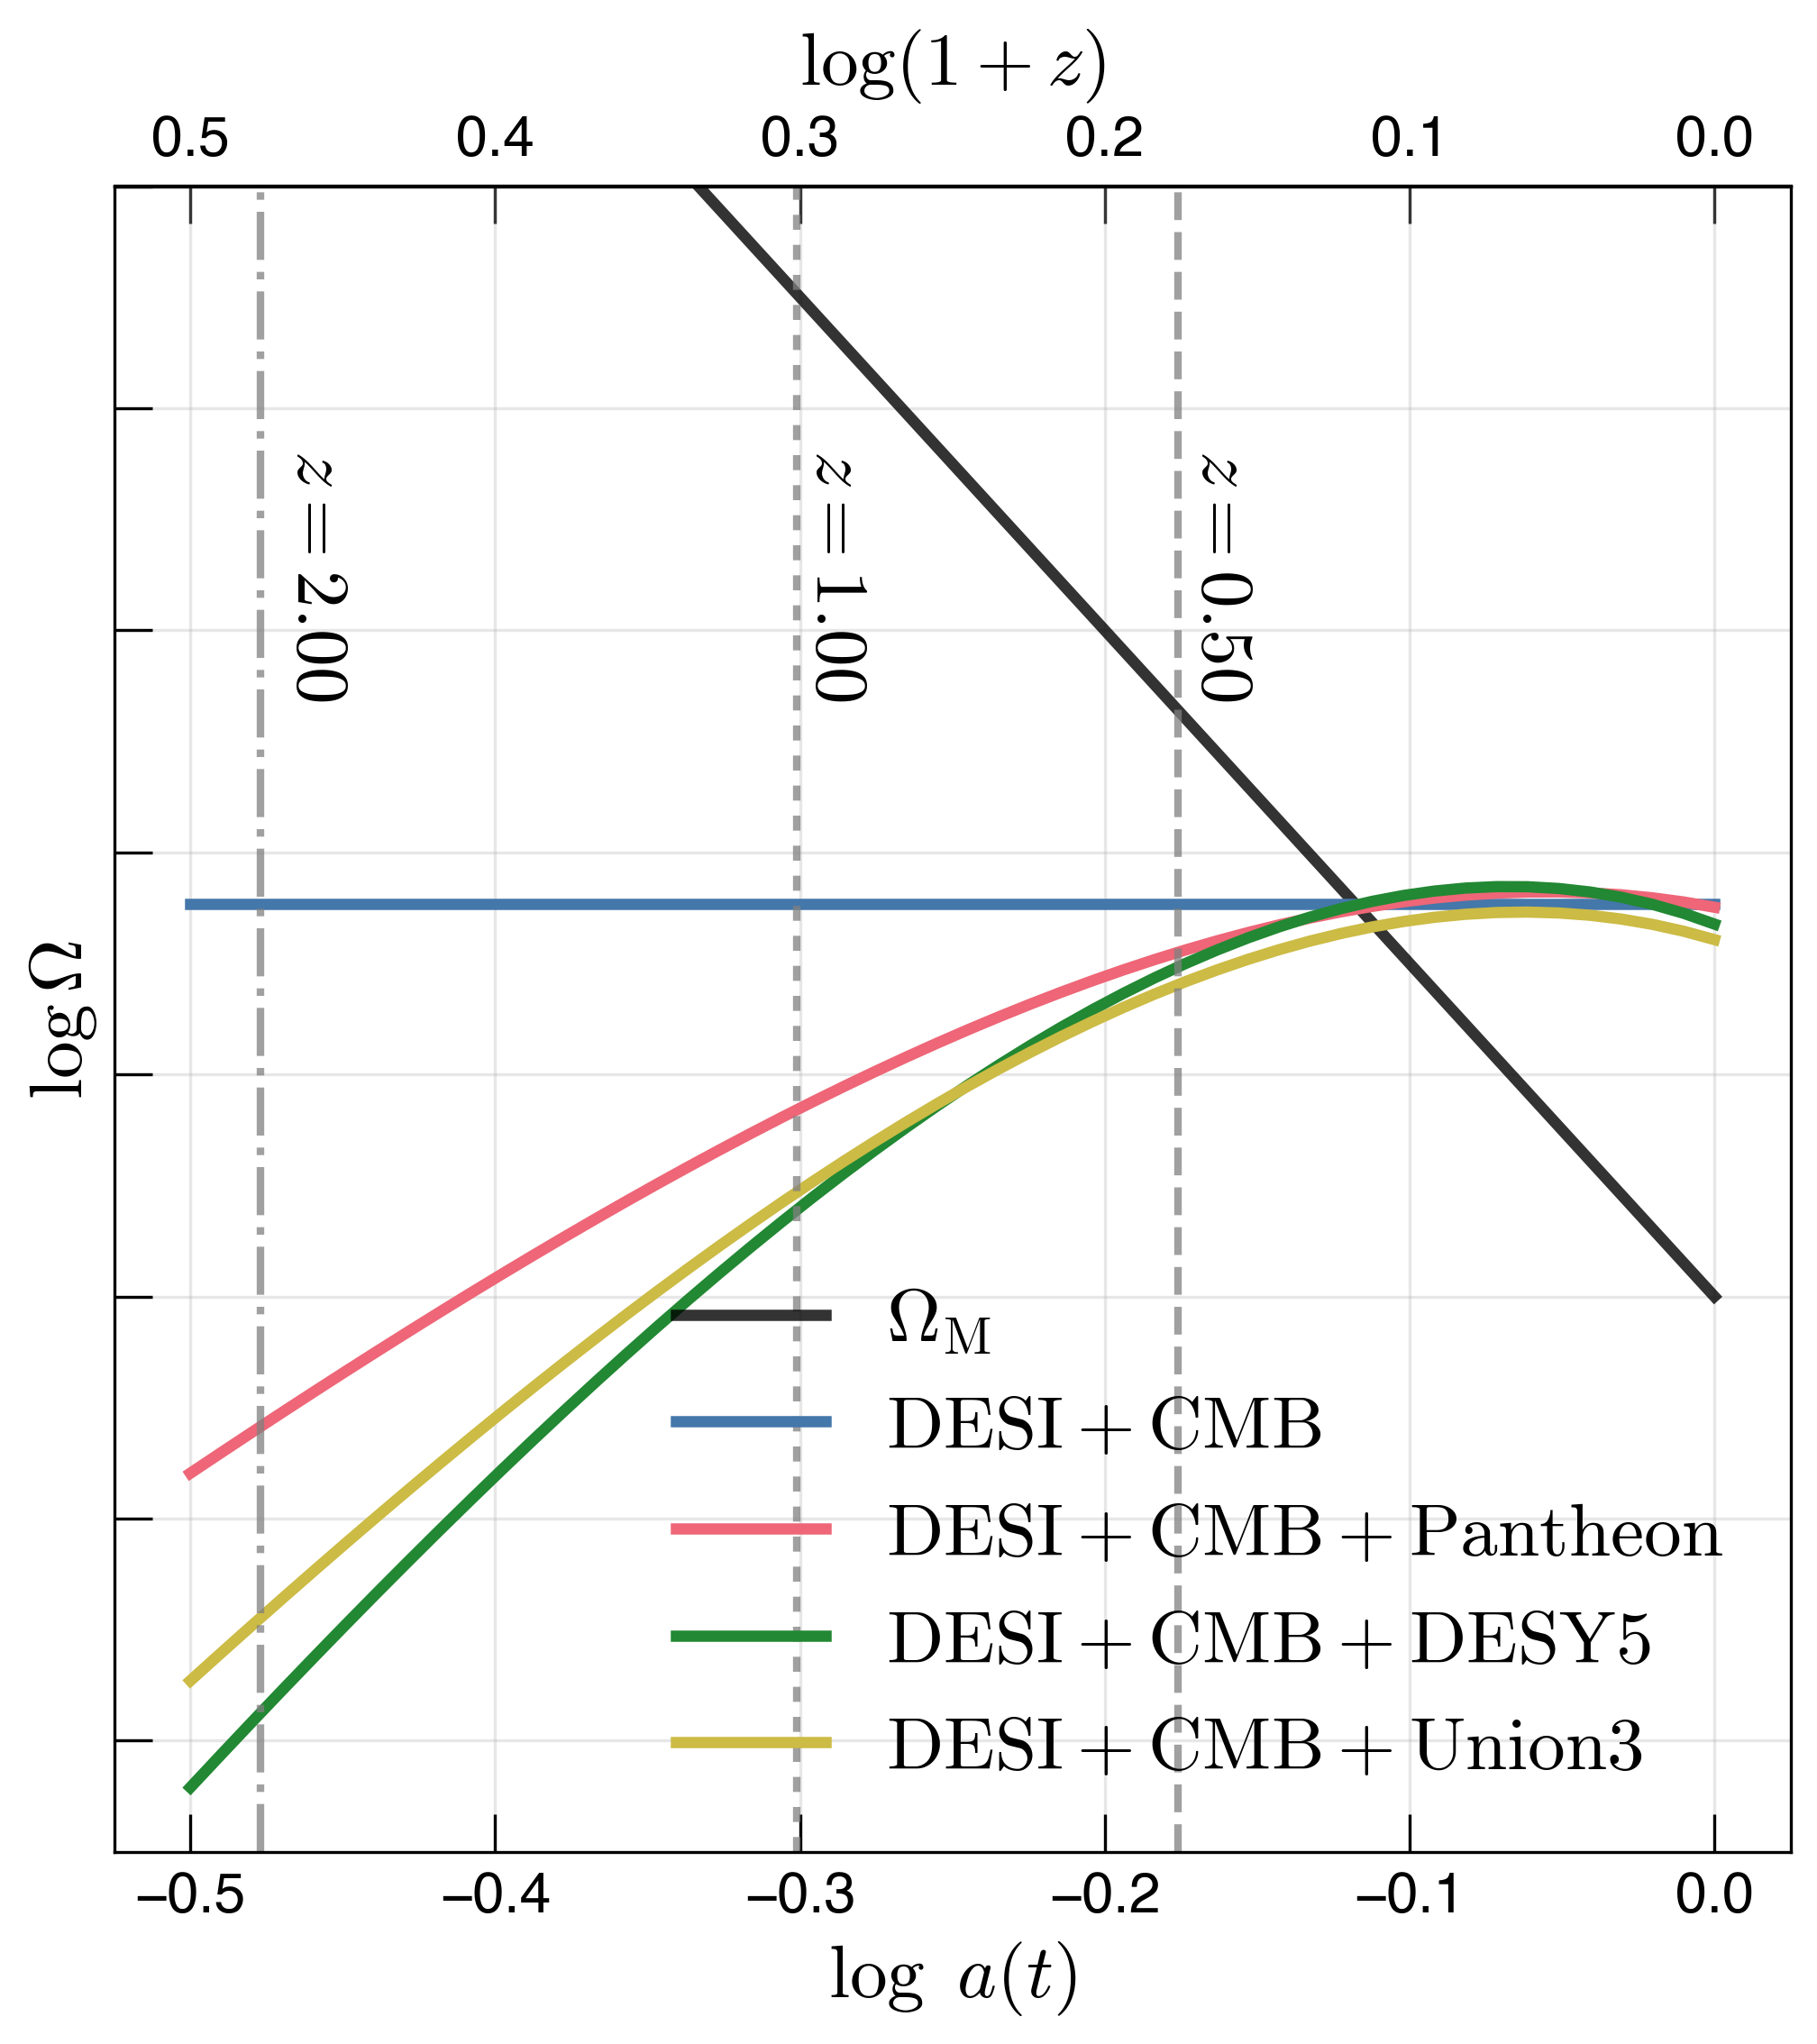

In [17]:
l_scale_factor = np.linspace(-0.5,0)

fig, ax = plt.subplots(figsize=(8,8), nrows=1, ncols=1)

l_density_Matter = -3. * l_scale_factor

_ = ax.plot(l_scale_factor, l_density_Matter, c='k', label=Matter_label, alpha=0.8)


# DESI + CMB
OmegaM = 0.3069
OmegaL = 1. - OmegaM
w0, wa = -1., -0.
A = OmegaL / OmegaM
l_density_DE = np.log10(A) - 3. * (1. + w0 + wa * (1. - 10**l_scale_factor)) * (l_scale_factor)
_ = ax.plot(l_scale_factor, l_density_DE, label=strlabel_DESICMB)

# DESI + CMB + Pantheon
OmegaM = 0.3085
OmegaL = 1. - OmegaM
w0, wa = -0.827, -0.75
A = OmegaL / OmegaM
l_density_DE = np.log10(A) - 3. * (1. + w0 + wa * (1. - 10**l_scale_factor)) * (l_scale_factor)
_ = ax.plot(l_scale_factor, l_density_DE, label=strlabel_Pantheon)

# DESI + CMB + DESY5
OmegaM = 0.316
OmegaL = 1. - OmegaM
w0, wa = -0.65, -1.27
A = OmegaL / OmegaM
l_density_DE = np.log10(A) - 3. * (1. + w0 + wa * (1. - 10**l_scale_factor)) * (l_scale_factor)
_ = ax.plot(l_scale_factor, l_density_DE, label=strlabel_DESY5)

# DESI + CMB + Union3
OmegaM = 0.323
OmegaL = 1. - OmegaM
w0, wa = -0.727, -1.05
A = OmegaL / OmegaM
l_density_DE = np.log10(A) - 3. * (1. + w0 + wa * (1. - 10**l_scale_factor)) * (l_scale_factor)
_ = ax.plot(l_scale_factor, l_density_DE, label=strlabel_Union3)

_ = ax.axvline(np.log10(a_lookref_0), c='gray', ls='--', lw=2, alpha=0.75)
_ = ax.axvline(np.log10(a_lookref_1), c='gray', ls=':', lw=2, alpha=0.75)
_ = ax.axvline(np.log10(a_lookref_2), c='gray', ls='-.', lw=2, alpha=0.75)

x_redshift = 0.64
y_redshift = 0.70
_ = ax.annotate(strlabel_lookref_0, xy=(x_redshift, y_redshift), xycoords='axes fraction', 
                fontsize=20, rotation=270)

x_redshift = 0.41
y_redshift = 0.70
_ = ax.annotate(strlabel_lookref_1, xy=(x_redshift, y_redshift), xycoords='axes fraction', 
                fontsize=20, rotation=270)

x_redshift = 0.10
y_redshift = 0.70
_ = ax.annotate(strlabel_lookref_2, xy=(x_redshift, y_redshift), xycoords='axes fraction', 
                fontsize=20, rotation=270)

_ = ax.set_xlabel(r"$\log\ a(t) $", fontsize=20)
_ = ax.set_ylabel(r'$\log \Omega$', fontsize=20)

_ = ax.set_ylim(-0.5,1.)

ax2x = ax.secondary_xaxis('top', functions=(la2l1z, l1z2la))
_ = ax2x.set_xlabel(r"$\log (1+z)$", fontsize=20, labelpad=8)

_ = ax.legend(loc='lower right', facecolor='pink')
_ = ax.grid(alpha=0.3)

_ = ax.tick_params(which='both', axis='both', labelbottom=True, labelleft=False)

_ = plt.savefig('CosmoBudget_DESI_ZoomIn.png', bbox_inches='tight', dpi=256)

In [18]:
def a2z(a):
    return (1. / a) - 1.

def z2a(z):
    return 1. / (1. + z)



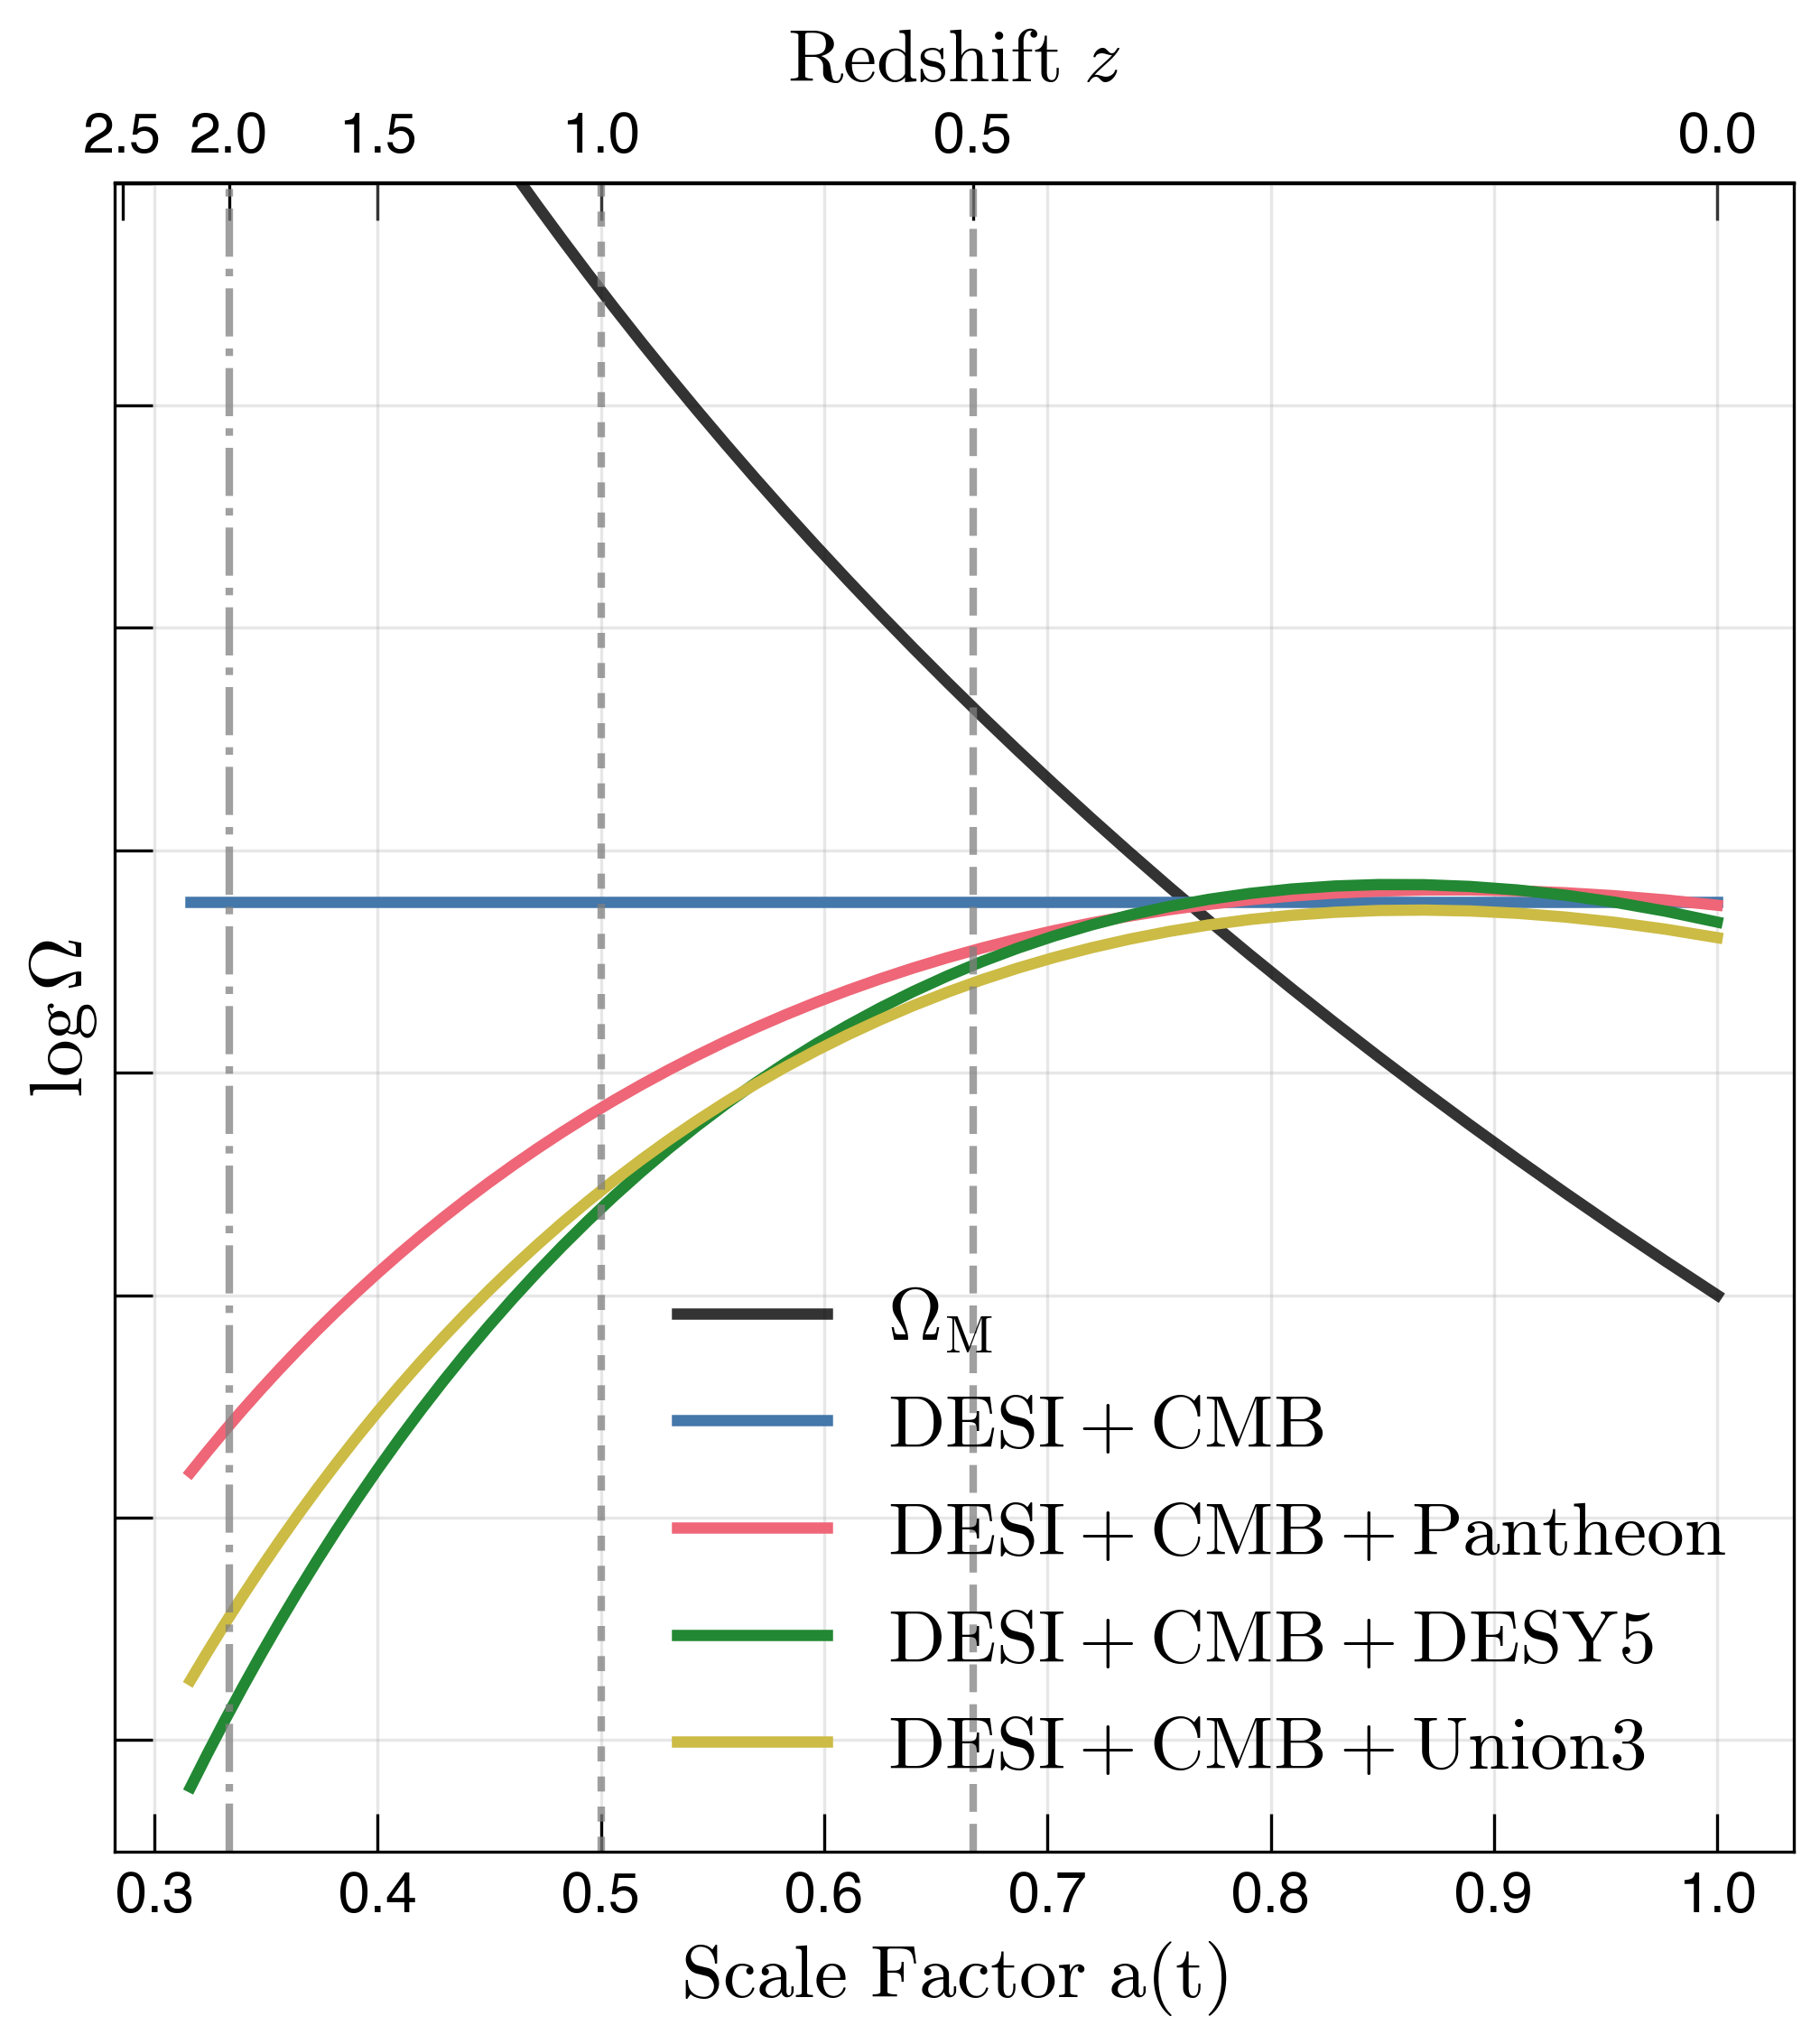

In [19]:
l_scale_factor = np.linspace(-0.5,0)

fig, ax = plt.subplots(figsize=(8,8), nrows=1, ncols=1)

l_density_Matter = -3. * l_scale_factor

_ = ax.plot(10**l_scale_factor, l_density_Matter, c='k', label=Matter_label, alpha=0.8)


# DESI + CMB
OmegaM = 0.3069
OmegaL = 1. - OmegaM
w0, wa = -1., -0.
A = OmegaL / OmegaM
l_density_DE = np.log10(A) - 3. * (1. + w0 + wa * (1. - 10**l_scale_factor)) * (l_scale_factor)
_ = ax.plot(10**l_scale_factor, l_density_DE, label=strlabel_DESICMB)

# DESI + CMB + Pantheon
OmegaM = 0.3085
OmegaL = 1. - OmegaM
w0, wa = -0.827, -0.75
A = OmegaL / OmegaM
l_density_DE = np.log10(A) - 3. * (1. + w0 + wa * (1. - 10**l_scale_factor)) * (l_scale_factor)
_ = ax.plot(10**l_scale_factor, l_density_DE, label=strlabel_Pantheon)

# DESI + CMB + DESY5
OmegaM = 0.316
OmegaL = 1. - OmegaM
w0, wa = -0.65, -1.27
A = OmegaL / OmegaM
l_density_DE = np.log10(A) - 3. * (1. + w0 + wa * (1. - 10**l_scale_factor)) * (l_scale_factor)
_ = ax.plot(10**l_scale_factor, l_density_DE, label=strlabel_DESY5)

# DESI + CMB + Union3
OmegaM = 0.323
OmegaL = 1. - OmegaM
w0, wa = -0.727, -1.05
A = OmegaL / OmegaM
l_density_DE = np.log10(A) - 3. * (1. + w0 + wa * (1. - 10**l_scale_factor)) * (l_scale_factor)
_ = ax.plot(10**l_scale_factor, l_density_DE, label=strlabel_Union3)

_ = ax.axvline(a_lookref_0, c='gray', ls='--', lw=2, alpha=0.75)
_ = ax.axvline(a_lookref_1, c='gray', ls=':', lw=2, alpha=0.75)
_ = ax.axvline(a_lookref_2, c='gray', ls='-.', lw=2, alpha=0.75)

_ = ax.set_xlabel(r"$\rm{Scale}\ \rm{Factor}\ a(t) $", fontsize=20)
_ = ax.set_ylabel(r'$\log \Omega$', fontsize=20)

_ = ax.set_ylim(-0.5,1.)

ax2x = ax.secondary_xaxis('top', functions=(a2z, z2a))
_ = ax2x.set_xlabel(r"$\rm{Redshift}$" + r"$\ z$", fontsize=20, labelpad=8)

_ = ax.legend(loc='lower right')
_ = ax.grid(alpha=0.3)

_ = ax.tick_params(which='both', axis='both', labelbottom=True, labelleft=False)

_ = plt.savefig('CosmoBudget_DESI_ZoomIn_Linear.png', bbox_inches='tight', dpi=256)